# Algoritmos de búsqueda con oráculo: Grover

Grover busca un elemento marcado entre `N` elementos sin ordenar, con una ventaja cuadrática sobre cualquier búsqueda clásica: donde clásicamente hacen falta del orden de `N` consultas al oráculo, Grover necesita del orden de `√N`. Este notebook construye el caso más pequeño con ventaja real: 2 qubits, 4 elementos, resuelto con una sola iteración.

## El oráculo de Grover

A diferencia del oráculo de Deutsch-Jozsa, que acumula `f(x)` en un qubit auxiliar, el oráculo de Grover marca el elemento buscado directamente con un cambio de fase, sin qubit auxiliar: `|x⟩ → -|x⟩` si `x` es el elemento marcado, `|x⟩ → |x⟩` en cualquier otro caso.

Para marcar `|11⟩` con 2 qubits, esa puerta es exactamente CZ: cambia la fase solo cuando los dos qubits valen 1.

## El difusor

Marcar el elemento no basta: su amplitud sigue siendo pequeña, indistinguible al medir. El difusor invierte todas las amplitudes respecto a su media, lo que aumenta la del elemento marcado y reduce las del resto. Se construye con H, X y otra vez la puerta que marca fase, aplicada esta vez sobre `|00⟩` en vez de sobre el elemento buscado.

In [1]:
import polypus

qc = polypus.Circuit(2)
qc.h(0)
qc.h(1)  # superposicion uniforme sobre los 4 elementos

qc.cz(0, 1)  # oraculo: marca |11>

qc.h(0)  # difusor
qc.h(1)
qc.x(0)
qc.x(1)
qc.cz(0, 1)
qc.x(0)
qc.x(1)
qc.h(0)
qc.h(1)

qc.measure_all()

Circuit(num_qubits=2, num_params=0, gates=13)

Con el patrón visto en [`02b`](02b_interoperabilidad_qiskit_qasm.ipynb):

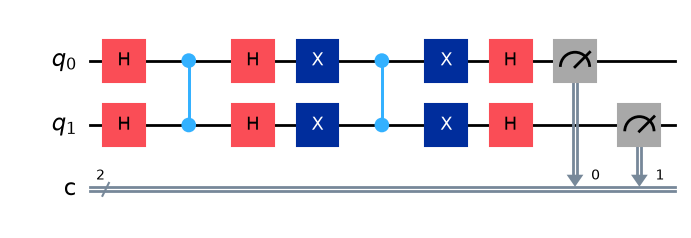

In [2]:
from qiskit import qasm2

qc_dibujo = qasm2.loads(
    qc.to_qasm2(), custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS
)
qc_dibujo.draw("mpl")

In [3]:
result = polypus.run_quantum_circuit(qc, shots=1000, infrastructure="local")
print(result.counts[0])

{'11': 1000}


El resultado es `'11'` el 100% de las veces: con una sola iteración de oráculo más difusor, y 4 elementos posibles, Grover encuentra el marcado con certeza. Con más elementos hacen falta más iteraciones, y deja de ser una certeza exacta para pasar a ser una probabilidad muy alta.

## Más allá de 2 qubits

El oráculo y el difusor de Grover para más de 2 qubits necesitan una puerta Z multi-controlada, que cambia la fase solo cuando todos los qubits de control valen 1 a la vez. Hay dos formas de conseguirla en Polypus.

La primera es descomponer una Toffoli, control de 2 qubits sobre un tercero, en primitivas de 1 y 2 qubits: se escribe con H, T, Tdg y CX. Vale la pena verla aunque exista una alternativa más directa, porque es la construcción clásica y explica por qué la T, vista en [`02a`](02a_puertas_y_construccion.ipynb), reaparece aquí:

In [4]:
def ccx_descompuesta(qc, a, b, c):
    qc.h(c)
    qc.cx(b, c)
    qc.tdg(c)
    qc.cx(a, c)
    qc.t(c)
    qc.cx(b, c)
    qc.tdg(c)
    qc.cx(a, c)
    qc.t(b)
    qc.t(c)
    qc.cx(a, b)
    qc.h(c)
    qc.t(a)
    qc.tdg(b)
    qc.cx(a, b)

Se comprueba igual que cualquier otra puerta, contra las cuatro combinaciones de entrada de una Toffoli real:

In [5]:
for a_val in (0, 1):
    for b_val in (0, 1):
        qc_prueba = polypus.Circuit(3)
        if a_val:
            qc_prueba.x(0)
        if b_val:
            qc_prueba.x(1)
        ccx_descompuesta(qc_prueba, 0, 1, 2)
        qc_prueba.measure_all()
        resultado = polypus.run_quantum_circuit(
            qc_prueba, shots=200, infrastructure="local"
        )
        print(f"a={a_val} b={b_val} ->", resultado.counts[0])

a=0 b=0 -> {'000': 200}
a=0 b=1 -> {'010': 200}
a=1 b=0 -> {'001': 200}
a=1 b=1 -> {'111': 200}


El qubit `c` solo se invierte cuando `a` y `b` valen 1 a la vez, exactamente el comportamiento de una Toffoli.

La segunda alternativa es la puerta nativa `ccx`, que hace lo mismo directamente, sin descomponer nada. Polypus también tiene `c3x` y `c4x` para 3 y 4 controles, si hicieran falta más:

In [6]:
qc_nativa = polypus.Circuit(3)
qc_nativa.x(0)
qc_nativa.x(1)
qc_nativa.ccx(0, 1, 2)
qc_nativa.measure_all()

resultado = polypus.run_quantum_circuit(qc_nativa, shots=200, infrastructure="local")
print(resultado.counts[0])

{'111': 200}


El resultado es idéntico al de la descomposición: `'111'`, con `a=1` y `b=1`.

## Resumen

Este notebook ha construido Grover para 2 qubits, encontrando el elemento marcado con una sola iteración y certeza total, y ha mostrado las dos formas de extender el oráculo y el difusor más allá de 2 qubits: descomponer una Toffoli a mano con H, T, Tdg y CX, viendo de qué está hecha por dentro, o usar directamente la puerta nativa `ccx` (y `c3x`/`c4x` para más controles).

La siguiente sección entrena circuitos parametrizados con datos, empezando por QAOA sobre el problema MaxCut.

## Siguiente paso

Continúa con: [`06a_entrenamiento_variacional.ipynb`](06a_entrenamiento_variacional.ipynb).